In [ ]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

n_wells = 200

data = {
    "Well_Name": [f"Well_{i+1}" for i in range(n_wells)],

    "X_Coordinate (m)": np.random.uniform(500, 5000, n_wells),
    "Y_Coordinate (m)": np.random.uniform(500, 5000, n_wells),

    "Normalized_Cumulative_Oil_Production (MMm3)": np.random.uniform(0.5, 5.0, n_wells),
    "Cumulative_Oil_Production_on_3M (MMm3)": np.random.uniform(0.5, 5.0, n_wells),

    "Porosity (fraction)": np.random.uniform(0.03, 0.35, n_wells),

    "Horizontal_Permeability (md)": np.random.uniform(0.05, 0.35, n_wells),
    "Vertical_Permeability (md)": np.random.uniform(5, 1500, n_wells),

    "Net_Thickness (m)": np.random.uniform(10, 180, n_wells),

    "Desired_Horizontal_Well_Length (m)": np.random.uniform(5, 50, n_wells),

    "Average_Oil_Flow_Rate_3Y (m3/day)": np.random.uniform(500, 2000, n_wells),
    "Average_Oil_Flow_Rate_3M (m3/day)": np.random.uniform(500, 4500, n_wells),

    "Average_Water_Flow_Rate_3Y (m3/day)": np.random.uniform(300, 4000, n_wells),
    "Average_Water_Flow_Rate_3M (m3/day)": np.random.uniform(50, 800, n_wells),

    "WOR_3Y": np.random.uniform(20, 500, n_wells),
    "WOR_3M": np.random.uniform(0.05, 0.20, n_wells)
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("dummy_well_dataset.csv", index=False)

print(df.head())
print("\nDataset Shape:", df.shape)

  Well_Name  X_Coordinate (m)  Y_Coordinate (m)  \
0    Well_1       2185.430535       3389.142408   
1    Well_2       4778.214379        878.629842   
2    Well_3       3793.972738       1227.329213   
3    Well_4       3193.963179       4543.493848   
4    Well_5       1202.083882       3228.930768   

   Normalized_Cumulative_Oil_Production (MMm3)  \
0                                     0.964057   
1                                     4.561488   
2                                     2.773636   
3                                     4.219059   
4                                     1.940223   

   Cumulative_Oil_Production_on_3M (MMm3)  Porosity (fraction)  \
0                                1.260208             0.256316   
1                                1.753657             0.078812   
2                                1.296547             0.214412   
3                                0.899161             0.224149   
4                                1.042861             0.165722

In [ ]:
PI = "Normalized_Cumulative_Oil_Production (MMm3)"

In [ ]:
df_pi = df[["Well_Name",
            "X_Coordinate (m)","Well_Name",
            "Y_Coordinate (m)",
            ]]


In [ ]:
x_df = (
    df.groupby("X_Coordinate (m)")[PI]
      .mean()
      .reset_index(name="Average_PI")
      .sort_values("X_Coordinate (m)")
)
y_df = (
    df.groupby("Y_Coordinate (m)")[PI]
      .mean()
      .reset_index(name="Average_PI")
      .sort_values("Y_Coordinate (m)")
)

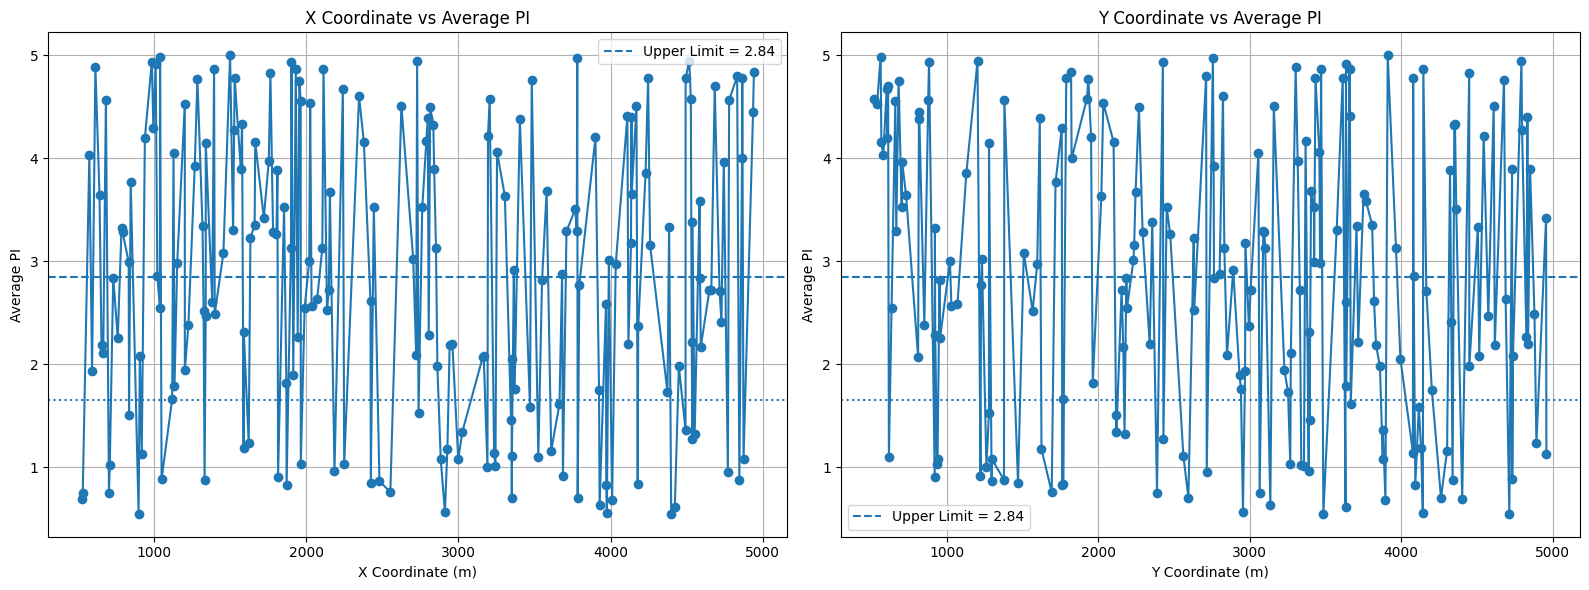

In [ ]:
import matplotlib.pyplot as plt

# Calculate limits
upper_limit_x = x_df["Average_PI"].mean()
lower_limit_x = x_df["Average_PI"].quantile(0.25)

upper_limit_y = y_df["Average_PI"].mean()
lower_limit_y = y_df["Average_PI"].quantile(0.25)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# X Coordinate vs PI
# -------------------------
axes[0].plot(
    x_df["X_Coordinate (m)"],
    x_df["Average_PI"],
    marker='o'
)

axes[0].axhline(
    upper_limit_x,
    linestyle='--',
    label=f'Upper Limit = {upper_limit_x:.2f}'
)

axes[0].axhline(
    lower_limit_x,
    linestyle=':'
)

axes[0].set_title("X Coordinate vs Average PI")
axes[0].set_xlabel("X Coordinate (m)")
axes[0].set_ylabel("Average PI")
axes[0].grid(True)
axes[0].legend()

# -------------------------
# Y Coordinate vs PI
# -------------------------
axes[1].plot(
    y_df["Y_Coordinate (m)"],
    y_df["Average_PI"],
    marker='o'
)

axes[1].axhline(
    upper_limit_y,
    linestyle='--',
    label=f'Upper Limit = {upper_limit_y:.2f}'
)

axes[1].axhline(
    lower_limit_y,
    linestyle=':'
)

axes[1].set_title("Y Coordinate vs Average PI")
axes[1].set_xlabel("Y Coordinate (m)")
axes[1].set_ylabel("Average PI")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def assign_rank(pi, upper, lower):
    if pi >= upper:
        return 1
    elif pi < lower:
        return 3
    else:
        return 2

x_df["PIX"] = x_df["Average_PI"].apply(
    lambda pi: assign_rank(pi, upper_limit_x, lower_limit_x)
)

y_df["PIY"] = y_df["Average_PI"].apply(
    lambda pi: assign_rank(pi, upper_limit_y, lower_limit_y)
)
print(x_df.head())
print(y_df.head())

   X_Coordinate (m)  Average_PI  PIX
0        524.849527    0.694220    3
1        531.284587    0.753690    3
2        574.645230    4.026439    1
3        592.630224    1.936911    2
4        614.386070    4.884777    1
   Y_Coordinate (m)  Average_PI  PIY
0        522.777127    4.574219    1
1        541.386732    4.529855    1
2        564.770699    4.984866    1
3        569.554774    4.157598    1
4        581.998215    4.026439    1


[np.float64(558.9662197411485), np.float64(584.8310945072017), np.float64(599.3175461179051), np.float64(648.7289213602104), np.float64(671.199026984313), np.float64(692.5498364946469), np.float64(774.9650000134169), np.float64(833.4297023473611), np.float64(841.945536995816), np.float64(861.279827408339), np.float64(930.4575554669503), np.float64(1022.0135473648926), np.float64(1038.3207342399405), np.float64(1044.4982714494397), np.float64(1123.2288685033432), np.float64(1131.1577440422348), np.float64(1149.930386669408), np.float64(1202.0460423139832), np.float64(1237.9874825133338), np.float64(1322.5208916998954), np.float64(1339.3850265612145), np.float64(1375.479015895284), np.float64(1383.1990296961415), np.float64(1397.8861991434367), np.float64(1432.7274779491684), np.float64(1582.9076994801462), np.float64(1630.8603554080648), np.float64(1811.974880956983), np.float64(1843.727286890331), np.float64(1859.9927530954221), np.float64(1895.8550773485133), np.float64(1910.886964775

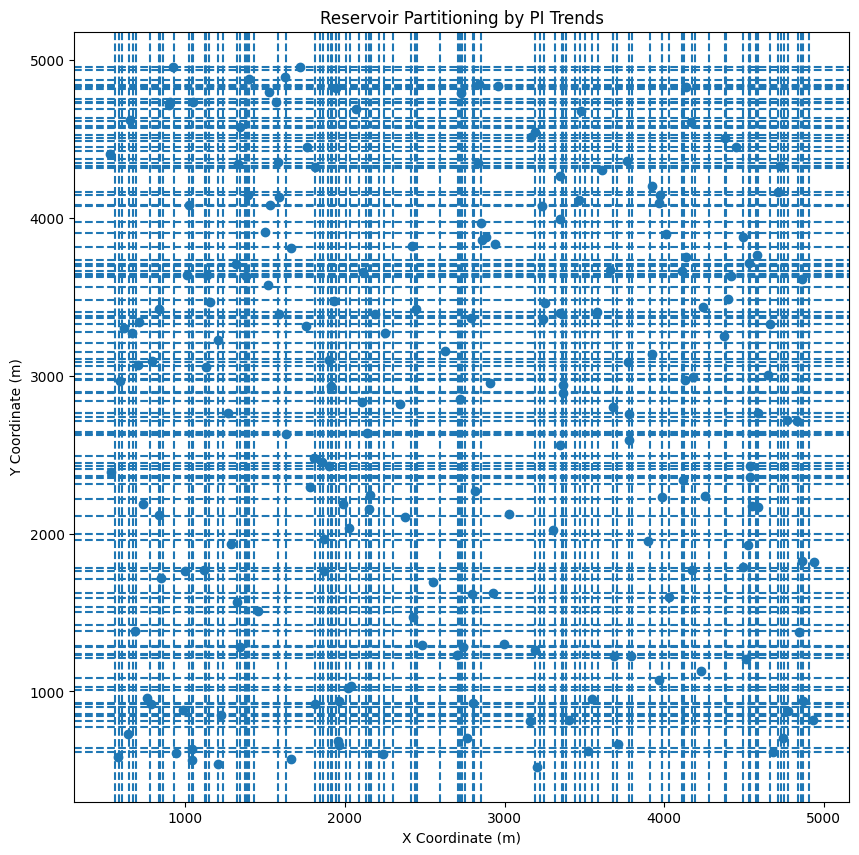

In [ ]:
import numpy as np

x_crossings = []

x = x_df["X_Coordinate (m)"].values
pi = x_df["Average_PI"].values

for i in range(len(x)-1):

    y1 = pi[i] - upper_limit_x
    y2 = pi[i+1] - upper_limit_x

    if y1 * y2 < 0:  # crossing occurs

        xc = x[i] + (x[i+1]-x[i]) * (
            (upper_limit_x - pi[i]) /
            (pi[i+1] - pi[i])
        )

        x_crossings.append(xc)

print(x_crossings)
y_crossings = []

y = y_df["Y_Coordinate (m)"].values
pi = y_df["Average_PI"].values

for i in range(len(y)-1):

    p1 = pi[i] - upper_limit_y
    p2 = pi[i+1] - upper_limit_y

    if p1 * p2 < 0:

        yc = y[i] + (y[i+1]-y[i]) * (
            (upper_limit_y - pi[i]) /
            (pi[i+1] - pi[i])
        )

        y_crossings.append(yc)

print(y_crossings)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# wells
ax.scatter(
    df["X_Coordinate (m)"],
    df["Y_Coordinate (m)"]
)

# vertical boundaries
for xc in x_crossings:
    ax.axvline(x=xc, linestyle='--')

# horizontal boundaries
for yc in y_crossings:
    ax.axhline(y=yc, linestyle='--')

ax.set_xlabel("X Coordinate (m)")
ax.set_ylabel("Y Coordinate (m)")
ax.set_title("Reservoir Partitioning by PI Trends")

plt.show()

In [ ]:
df["PIX"] = df["X_Coordinate (m)"].map(
    x_df.set_index("X_Coordinate (m)")["PIX"]
)

df["PIY"] = df["Y_Coordinate (m)"].map(
    y_df.set_index("Y_Coordinate (m)")["PIY"]
)
df["Rank_Sum"] = df["PIX"] + df["PIY"]

def assign_wpi(rank_sum):
    if rank_sum <= 3:
        return 1
    elif rank_sum <= 5:
        return 2
    else:
        return 3

df["WPI"] = df["Rank_Sum"].apply(assign_wpi)

df["Rank_Sum"] = df["PIX"] + df["PIY"]

def assign_wpi(rank_sum):
    if rank_sum <= 3:
        return 1
    elif rank_sum <= 5:
        return 2
    else:  # rank_sum == 6
        return 3

df["WPI"] = df["Rank_Sum"].apply(assign_wpi)
print(df.head)

<bound method NDFrame.head of     Well_Name  X_Coordinate (m)  Y_Coordinate (m)  \
0      Well_1       2185.430535       3389.142408   
1      Well_2       4778.214379        878.629842   
2      Well_3       3793.972738       1227.329213   
3      Well_4       3193.963179       4543.493848   
4      Well_5       1202.083882       3228.930768   
..        ...               ...               ...   
195  Well_196       2071.443086       4688.407965   
196  Well_197       3766.800555       4362.857383   
197  Well_198       4536.996170       2430.473123   
198  Well_199       4491.888909       3878.919805   
199  Well_200       4009.439956       3895.442933   

     Normalized_Cumulative_Oil_Production (MMm3)  \
0                                       0.964057   
1                                       4.561488   
2                                       2.773636   
3                                       4.219059   
4                                       1.940223   
..                   

In [ ]:
x_crossings = sorted(x_crossings)
y_crossings = sorted(y_crossings)

df["sector_x"] = np.digitize(
    df["X_Coordinate (m)"],
    x_crossings
)

df["sector_y"] = np.digitize(
    df["Y_Coordinate (m)"],
    y_crossings
)

df["Sector"] = (
    "S_"
    + df["sector_x"].astype(str)
    + "_"
    + df["sector_y"].astype(str)
)

sector_stats = (
    df.groupby("Sector")
      .agg(
          well_count=("WPI", "count"),
          wpi_sum=("WPI", "sum")
      )
      .reset_index()
)



def assign_sector_wpi(row):

    wc = row["well_count"]
    ws = row["wpi_sum"]

    if wc <= ws <= wc + 1:
        return 1

    elif wc + 1 < ws <= (2 * wc + 1):
        return 2

    elif (2 * wc + 1) < ws <= (3 * wc):
        return 3

    else:
        return np.nan

sector_stats["Sector_WPI"] = sector_stats.apply(
    assign_sector_wpi,
    axis=1
)

# =====================================================
# STEP 6: Merge sector WPI back to wells
# =====================================================

df = df.merge(
    sector_stats[["Sector", "Sector_WPI"]],
    on="Sector",
    how="left"
)
print(df.head)

<bound method NDFrame.head of     Well_Name  X_Coordinate (m)  Y_Coordinate (m)  \
0      Well_1       2185.430535       3389.142408   
1      Well_2       4778.214379        878.629842   
2      Well_3       3793.972738       1227.329213   
3      Well_4       3193.963179       4543.493848   
4      Well_5       1202.083882       3228.930768   
..        ...               ...               ...   
195  Well_196       2071.443086       4688.407965   
196  Well_197       3766.800555       4362.857383   
197  Well_198       4536.996170       2430.473123   
198  Well_199       4491.888909       3878.919805   
199  Well_200       4009.439956       3895.442933   

     Normalized_Cumulative_Oil_Production (MMm3)  \
0                                       0.964057   
1                                       4.561488   
2                                       2.773636   
3                                       4.219059   
4                                       1.940223   
..                   

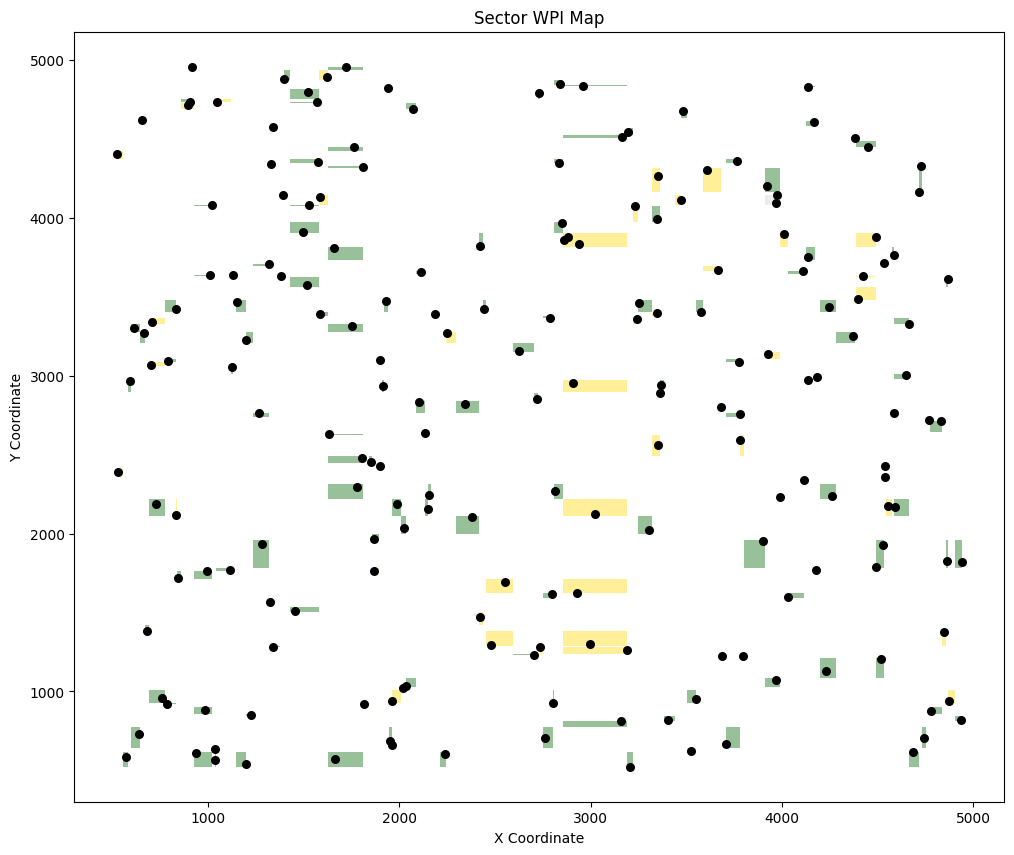

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12,10))

x_bounds = [
    df["X_Coordinate (m)"].min(),
    *x_crossings,
    df["X_Coordinate (m)"].max()
]

y_bounds = [
    df["Y_Coordinate (m)"].min(),
    *y_crossings,
    df["Y_Coordinate (m)"].max()
]

sector_lookup = sector_stats.set_index("Sector")["Sector_WPI"]

for i in range(len(x_bounds)-1):

    for j in range(len(y_bounds)-1):

        sector_name = f"S_{i}_{j}"

        if sector_name not in sector_lookup.index:
            continue

        sector_wpi = sector_lookup[sector_name]

        if sector_wpi == 1:
            color = "darkgreen"

        elif sector_wpi == 2:
            color = "gold"

        else:
            color = "lightgray"

        rect = Rectangle(
            (x_bounds[i], y_bounds[j]),
            x_bounds[i+1]-x_bounds[i],
            y_bounds[j+1]-y_bounds[j],
            alpha=0.4,
            facecolor=color
        )

        ax.add_patch(rect)

ax.scatter(
    df["X_Coordinate (m)"],
    df["Y_Coordinate (m)"],
    color="black",
    s=30
)

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("Sector WPI Map")

plt.show()

In [ ]:
pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.1 MB/s eta 0:00:00


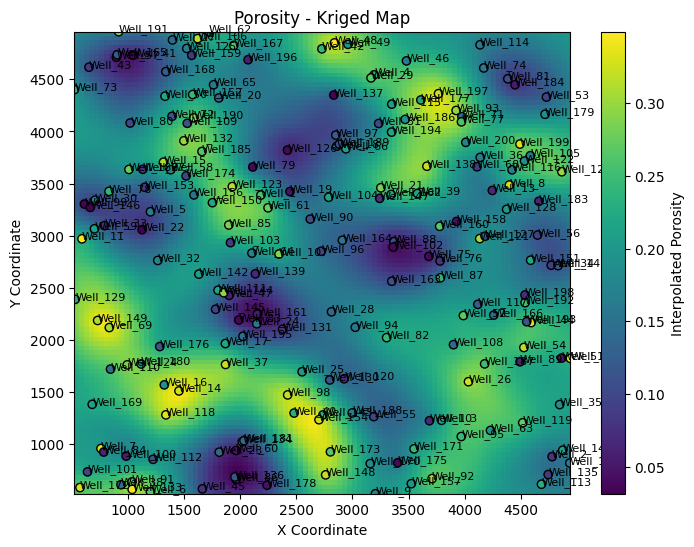

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from pykrige.ok import OrdinaryKriging

# -----------------------------
# Data
# -----------------------------

x = df["X_Coordinate (m)"].values
y = df["Y_Coordinate (m)"].values
z = df["Porosity (fraction)"].values

# -----------------------------
# Create interpolation grid
# -----------------------------

gridx = np.linspace(x.min(), x.max(), 100)
gridy = np.linspace(y.min(), y.max(), 100)

# -----------------------------
# Ordinary Kriging
# -----------------------------

OK = OrdinaryKriging(
    x,
    y,
    z,
    variogram_model="spherical",
    verbose=False,
    enable_plotting=False
)

zgrid, ss = OK.execute(
    "grid",
    gridx,
    gridy
)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    zgrid,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    aspect="auto"
)

plt.scatter(
    x,
    y,
    c=z,
    edgecolors="black"
)

for i, well in enumerate(df["Well_Name"]):
    plt.text(x[i], y[i], well, fontsize=8)

plt.colorbar(label="Interpolated Porosity")

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.title("Porosity - Kriged Map")

plt.show()

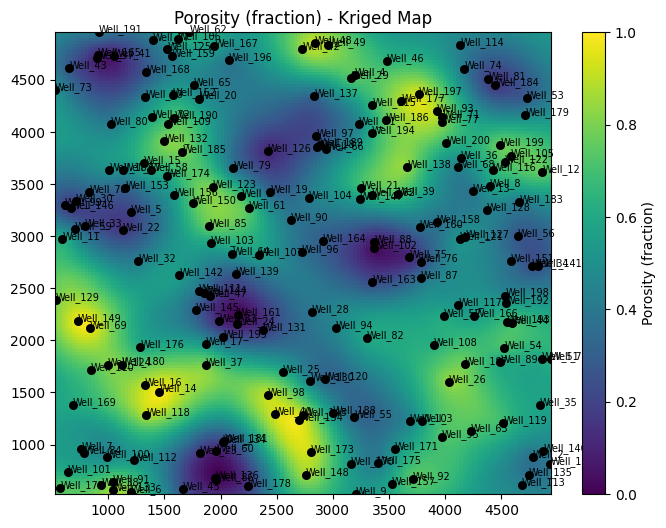

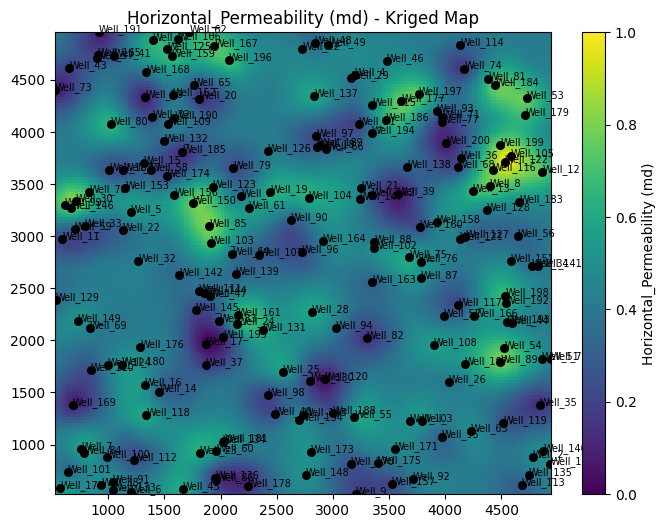

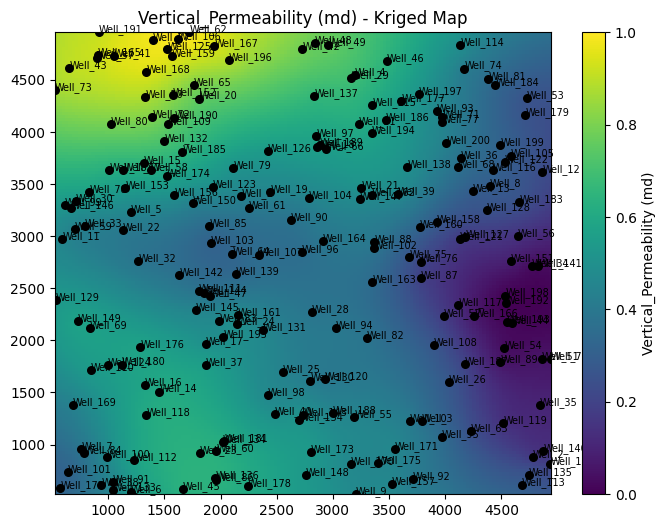

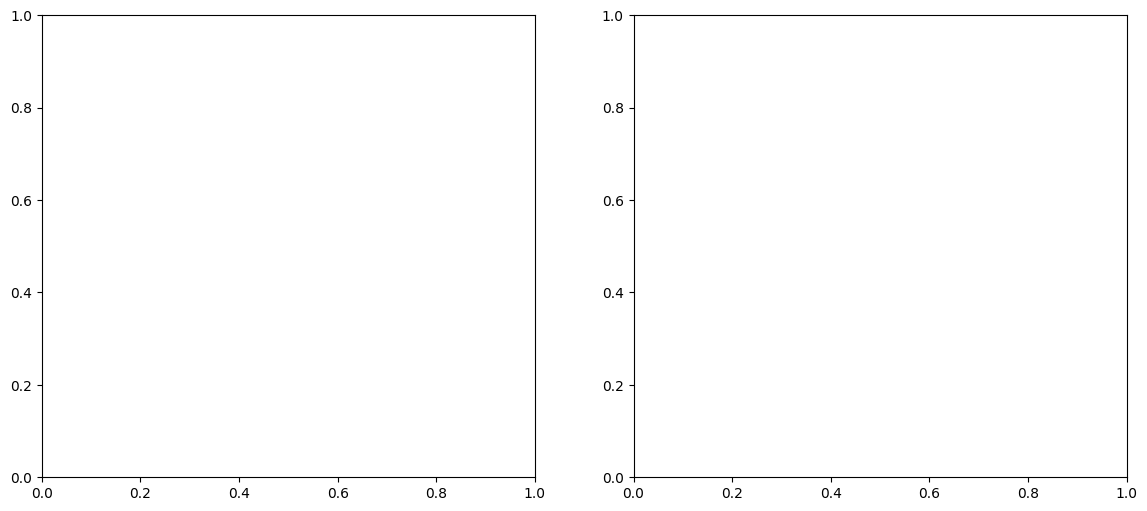

In [27]:
from pykrige.ok import OrdinaryKriging

def kriged_map(df, property_col):

    x = df["X_Coordinate (m)"].values
    y = df["Y_Coordinate (m)"].values
    z = df[property_col].values

    gridx = np.linspace(x.min(), x.max(), 150)
    gridy = np.linspace(y.min(), y.max(), 150)

    OK = OrdinaryKriging(
        x,
        y,
        z,
        variogram_model="spherical"
    )

    zgrid, ss = OK.execute(
        "grid",
        gridx,
        gridy
    )

    plt.figure(figsize=(8,6))

    plt.imshow(
        zgrid,
        extent=[
            x.min(),
            x.max(),
            y.min(),
            y.max()
        ],
        origin="lower",
        aspect="auto"
    )

    plt.scatter(
        x,
        y,
        c="black",
        s=30
    )

    for i, well in enumerate(df["Well_Name"]):
        plt.text(
            x[i],
            y[i],
            well,
            fontsize=7
        )

    plt.colorbar(label=property_col)

    plt.title(
        f"{property_col} - Kriged Map"
    )

    plt.show()




kriged_map(df, "Porosity (fraction)")
kriged_map(df,  "Horizontal_Permeability (md)")
kriged_map(df,  "Vertical_Permeability (md)"
)
fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 6)
)













In [28]:
phi_upper = df["Porosity (fraction)"].quantile(0.75)
phi_lower = df["Porosity (fraction)"].quantile(0.25)


kh_upper = df["Horizontal_Permeability (md)"].quantile(0.75)
kh_lower = df["Horizontal_Permeability (md)"].quantile(0.25)

sector_props = (
    df.groupby("Sector")
      .agg(
          Phi_avg=("Porosity (fraction)", "mean"),
          Kh_avg=("Horizontal_Permeability (md)", "mean")
      )
      .reset_index()
)

def phi_index(phi):

    if phi >= phi_upper:
        return 1

    elif phi <= phi_lower:
        return 3

    else:
        return 2




sector_props["Phi_I"] = (
    sector_props["Phi_avg"]
    .apply(phi_index)
)

def kh_index(kh):

    if kh >= kh_upper:
        return 1

    elif kh <= kh_lower:
        return 3

    else:
        return 2



sector_props["Kh_I"] = (
    sector_props["Kh_avg"]
    .apply(kh_index)
)


print(
    sector_props[
        [
            "Sector",
            "Phi_avg",
            "Phi_I",
            "Kh_avg",
            "Kh_I"
        ]
    ]
)

       Sector   Phi_avg  Phi_I    Kh_avg  Kh_I
0      S_0_33  0.232713      2  0.161807     2
1      S_0_81  0.236080      2  0.062628     3
2    S_10_101  0.285813      1  0.070205     3
3     S_10_91  0.041696      3  0.280156     2
4     S_10_93  0.122382      2  0.098228     3
..        ...       ...    ...       ...   ...
190   S_97_62  0.298447      1  0.346300     1
191    S_98_9  0.214485      2  0.227722     2
192   S_99_26  0.332757      1  0.136172     2
193    S_99_4  0.164007      2  0.235583     2
194    S_9_24  0.151502      2  0.096169     3

[195 rows x 5 columns]


In [29]:
sector_props["Phi_I"]
sector_props["Kh_I"]


sector_props["HI_Sum"] = (
    sector_props["Phi_I"] +
    sector_props["Kh_I"]
)
def assign_hi(rank_sum):

    if rank_sum <= 3:
        return 1

    elif rank_sum <= 5:
        return 2

    else:  # rank_sum == 6
        return 3

sector_props["HI"] = (
    sector_props["HI_Sum"]
    .apply(assign_hi)
)

print(
    sector_props[
        [
            "Sector",
            "Phi_I",
            "Kh_I",
            "HI"
        ]
    ]
)

       Sector  Phi_I  Kh_I  HI
0      S_0_33      2     2   2
1      S_0_81      2     3   2
2    S_10_101      1     3   2
3     S_10_91      3     2   2
4     S_10_93      2     3   2
..        ...    ...   ...  ..
190   S_97_62      1     1   1
191    S_98_9      2     2   2
192   S_99_26      1     2   1
193    S_99_4      2     2   2
194    S_9_24      2     3   2

[195 rows x 4 columns]


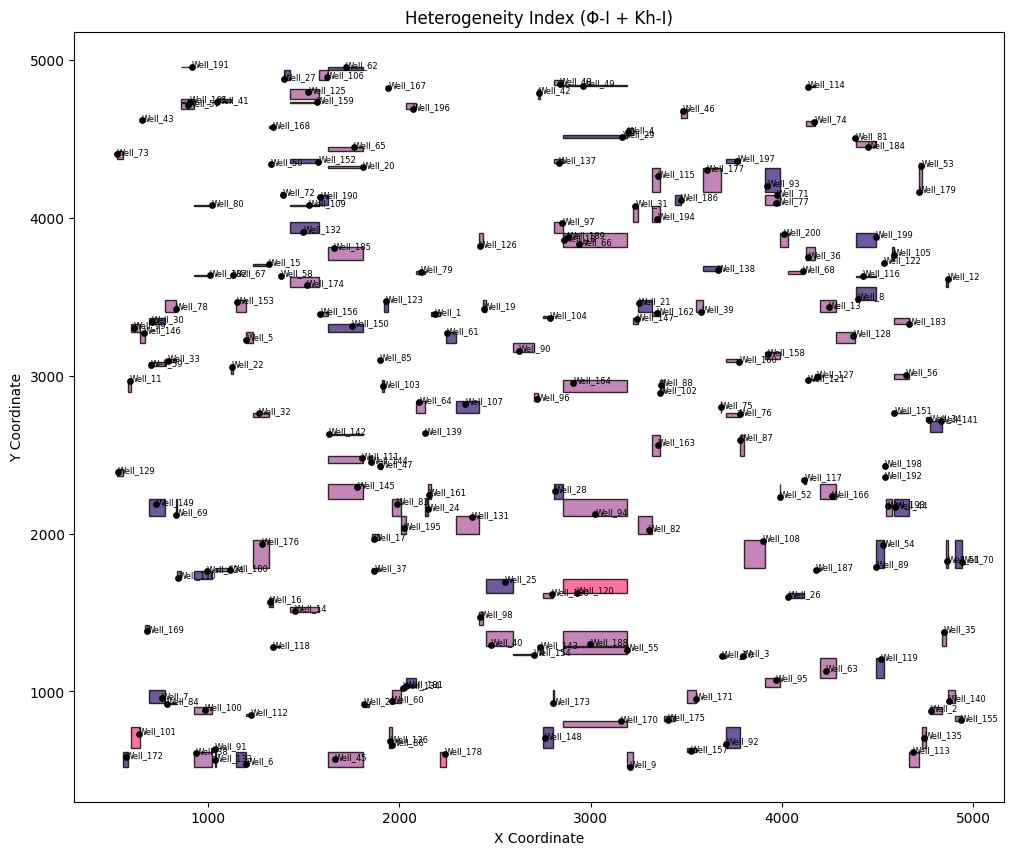

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12,10))

x_bounds = [
    df["X_Coordinate (m)"].min(),
    *sorted(x_crossings),
    df["X_Coordinate (m)"].max()
]

y_bounds = [
    df["Y_Coordinate (m)"].min(),
    *sorted(y_crossings),
    df["Y_Coordinate (m)"].max()
]

sector_lookup = (
    sector_props
    .set_index("Sector")["HI"]
    .to_dict()
)

for i in range(len(x_bounds)-1):

    for j in range(len(y_bounds)-1):

        sector_name = f"S_{i}_{j}"

        if sector_name not in sector_lookup:
            continue

        hi = sector_lookup[sector_name]

        if hi == 1:
            color = "#4b2e83"   # dark
            label = "HI 1"

        elif hi == 2:
            color = "#b565a7"   # medium
            label = "HI 2"

        else:
            color = "#ff4f88"   # light/pink
            label = "HI 3"

        rect = Rectangle(
            (x_bounds[i], y_bounds[j]),
            x_bounds[i+1]-x_bounds[i],
            y_bounds[j+1]-y_bounds[j],
            facecolor=color,
            alpha=0.8,
            edgecolor="black"
        )

        ax.add_patch(rect)

# Plot wells
ax.scatter(
    df["X_Coordinate (m)"],
    df["Y_Coordinate (m)"],
    color="black",
    s=15
)

# Well labels
for _, row in df.iterrows():

    ax.text(
        row["X_Coordinate (m)"],
        row["Y_Coordinate (m)"],
        row["Well_Name"],
        fontsize=6
    )

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("Heterogeneity Index (Φ-I + Kh-I)")

plt.show()

       Sector  Sector_WPI  HI  Hybrid_Score                Category
0      S_0_33           2   2             4      Moderate Potential
1      S_0_81           2   2             4      Moderate Potential
2    S_10_101           2   2             4      Moderate Potential
3     S_10_91           2   2             4      Moderate Potential
4     S_10_93           1   2             3  Near Maximum Potential
..        ...         ...  ..           ...                     ...
190   S_97_62           1   1             2              Sweet Spot
191    S_98_9           2   2             4      Moderate Potential
192   S_99_26           1   1             2              Sweet Spot
193    S_99_4           1   2             3  Near Maximum Potential
194    S_9_24           1   2             3  Near Maximum Potential

[195 rows x 5 columns]


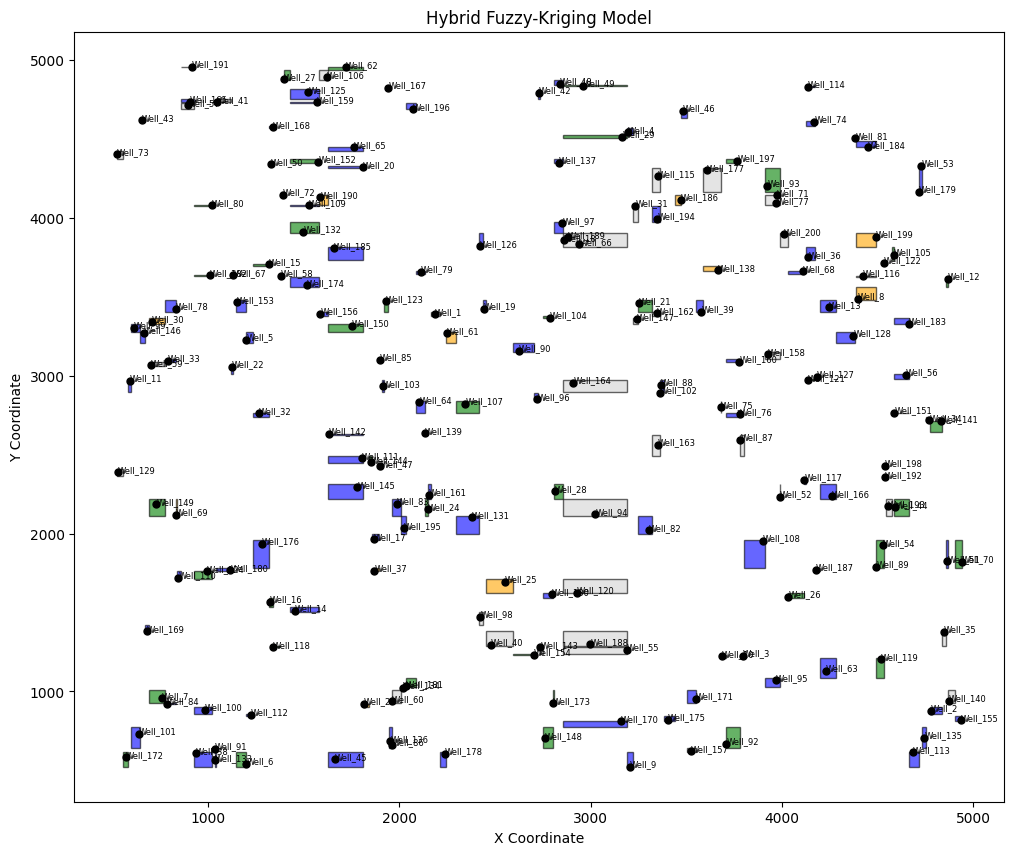

In [33]:
# =====================================
# Merge HI and Sector_WPI
# =====================================

sector_hybrid = sector_stats.merge(
    sector_props[["Sector", "HI"]],
    on="Sector",
    how="inner"
)

# =====================================
# Hybrid Score
# =====================================

sector_hybrid["Hybrid_Score"] = (
    sector_hybrid["Sector_WPI"] +
    sector_hybrid["HI"]
)

# =====================================
# Sweet Spot Classification
# =====================================

def classify_sector(row):

    wpi = row["Sector_WPI"]
    hi = row["HI"]

    # Best reservoir + best production
    if wpi == 1 and hi == 1:
        return "Sweet Spot"

    # Good reservoir but production not matching
    elif hi == 1 and wpi > 1:
        return "Intervention Candidate"

    # Good production but poor reservoir
    elif wpi == 1 and hi > 1:
        return "Near Maximum Potential"

    # Poor reservoir and poor production
    elif wpi == 3 and hi == 3:
        return "Low Priority"

    else:
        return "Moderate Potential"


sector_hybrid["Category"] = (
    sector_hybrid.apply(
        classify_sector,
        axis=1
    )
)

# =====================================
# Display
# =====================================

print(
    sector_hybrid[
        [
            "Sector",
            "Sector_WPI",
            "HI",
            "Hybrid_Score",
            "Category"
        ]
    ]
)

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12,10))

x_bounds = [
    df["X_Coordinate (m)"].min(),
    *sorted(x_crossings),
    df["X_Coordinate (m)"].max()
]

y_bounds = [
    df["Y_Coordinate (m)"].min(),
    *sorted(y_crossings),
    df["Y_Coordinate (m)"].max()
]

hybrid_lookup = (
    sector_hybrid
    .set_index("Sector")["Category"]
    .to_dict()
)

for i in range(len(x_bounds)-1):

    for j in range(len(y_bounds)-1):

        sector_name = f"S_{i}_{j}"

        if sector_name not in hybrid_lookup:
            continue

        category = hybrid_lookup[sector_name]

        if category == "Sweet Spot":
            color = "green"

        elif category == "Intervention Candidate":
            color = "orange"

        elif category == "Near Maximum Potential":
            color = "blue"

        elif category == "Low Priority":
            color = "red"

        else:
            color = "lightgray"

        rect = Rectangle(
            (x_bounds[i], y_bounds[j]),
            x_bounds[i+1]-x_bounds[i],
            y_bounds[j+1]-y_bounds[j],
            facecolor=color,
            alpha=0.6,
            edgecolor="black"
        )

        ax.add_patch(rect)

# Plot wells
ax.scatter(
    df["X_Coordinate (m)"],
    df["Y_Coordinate (m)"],
    color="black",
    s=25
)

for _, row in df.iterrows():

    ax.text(
        row["X_Coordinate (m)"],
        row["Y_Coordinate (m)"],
        row["Well_Name"],
        fontsize=6
    )

ax.set_title("Hybrid Fuzzy-Kriging Model")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

plt.show()